
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [1]:
from controller import *
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-09-08  weekday:  1  day:  Tuesday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


Item batches: 154
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  CentralBuffer_Location
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_60
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_61
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_62
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_63
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  BW_(BKW_01)_Location
Machine Setup 162 BW_(BKW_01)_Location 671
Machine Loading 1049 BW_(BKW_01)_Location 792
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_64
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  OUT - Outsourced activity_(OUT - Outsourced)_Location
Machine Setup 186 OUT - Outsourced activity_(OUT - Outsourced)_Location 671
Machine Setup 189 OUT - Outsourced activity_(OUT - Outsourced)_Location 673
Machine Setup 217 OUT - Outsourced a

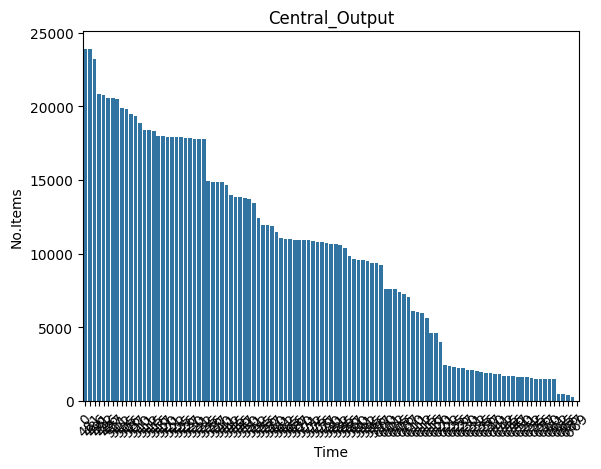

,BufferName,Time,No.Items
0,Central_Output,0,23888
1,Central_Output,481,23871
2,Central_Output,486,23233
3,Central_Output,491,20812
4,Central_Output,492,20788
...,...,...,...
95,Central_Output,647,1656
96,Central_Output,650,1638
97,Central_Output,651,1626
98,Central_Output,652,1545


______________________________


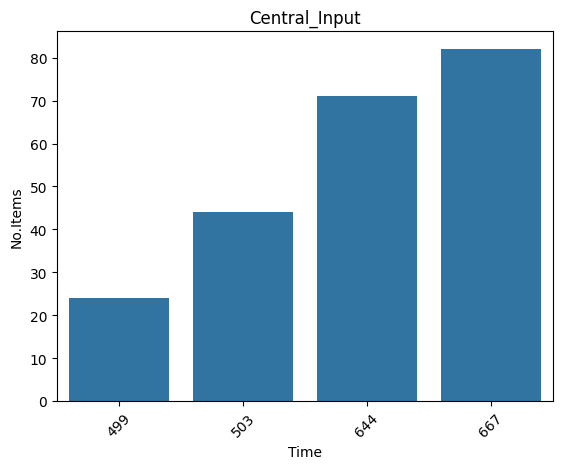

,BufferName,Time,No.Items
0,Central_Input,499,24
1,Central_Input,503,44
2,Central_Input,644,71
3,Central_Input,667,82


______________________________


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    #if start != end:
    #    display(sub_df)
    
    #    print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "BufferData.csv"))

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [ ]:
import pandas as pd

location_df = pd.read_csv(os.path.join("..", "data", "simulation", "LocationData.csv"))

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

In [ ]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))


In [ ]:
import pandas as pd

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

demands_df = exec_df.groupby(['Items','ID','Product','Work Orders/Operation','EventName','EventID','Resource','Date'])['SimTime'].agg(lambda x:list(x)).reset_index()

for demand in demands_df['ID'].unique():
    demand_df = demands_df[demands_df["ID"] == demand]
    demand_df['Date']  = pd.to_datetime(demand_df['Date'], format="%Y-%m-%d %H:%M:%S")
    display(demand_df)


In [ ]:
import pandas as pd 

milp_schedule_df = pd.read_csv(os.path.join("..", "data", "schedules", "TBRM_Plan_2026-08-19_R10_2026-09-01.csv"))

sim_schedule_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

sim_schedule_df = sim_schedule_df[["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Operation Order","Work Orders/Expected Duration","Work Orders/Start(SIM)","Work Orders/End(SIM)","Work Orders/Status(SIM)","Tardy(SIM)","Lateness (days)(SIM)"]]

schedule_df = pd.merge(milp_schedule_df, sim_schedule_df,  how="left", on=["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Operation Order","Work Orders/Expected Duration"])

schedule_df.to_csv(os.path.join("..", "data", "schedules", "Combined_Schedule.csv"),index = False)

In [ ]:
"""
             
            for j in EDDordered:
                for altmach in j.getOperation().getAlternativeResources():
                    if altmach.getName()== "OUT - Outsourced activity_(OUT - Outsourced)":
                        #schedule right here!
                        mymach = self.getMachineDict()[altmach]

                        jobest = j.getEarliestStart(self.getSchedulableJobs())

                    
                        shiftind = 0
                        currentshift = mymach.getMyShifts()[shiftind]

                        while currentshift.getEndTime() < jobest:
                            shiftind+=1
                            if shiftind >= len(mymach.getMyShifts())
                                currentshift = None
                                break
                            currentshift = mymach.getMyShifts()[shiftind]

                        startshift = currentshift 
                        

                        
                        if currentshift != None:
                            
                            process_start = max(jobest,currentshift.getStartTime())
                            
                            slotstart = currentshift.getStartTime()
                            timelength = mymach.getTimeLength(slotstart,mymach.getMyShifts()[-1].getEndTime())

                            if timelength >= j.getProcessTime():

                                currentslotshifts = []
        
                                currenttime = process_start
                                procss_shft_strt = currenttime
                                proctime = j.getProcessTime()
                                currentslotshifts.append(currentshift) 

                                if proctime <= currentshift.getEndTime() - procss_shft_strt: 
                                    currenttime = procss_shft_strt+proctime
                                    proctime = 0 
                                else:
                                    currenttime = currentshift.getEndTime()+1
                                    proctime -= (currentshift.getEndTime()+1 - procss_shft_strt)

                                
                                shftind = mymach.getMyShifts().index(currentshift)
                                    
                                while (shftind < len(mymach.getMyShifts())) & proctime > 0:
                                    shftind+=1
                                    if (shftind < len(mymach.getMyShifts())):
                                        currentshift = mymach.getMyShifts()[shftind]
                                        currentslotshifts.append(currentshift)
                                        procss_shft_strt = currentshift.getStartTime()
                                    if proctime <= currentshift.getEndTime() - procss_shft_strt:
                                        currenttime = procss_shft_strt+proctime
                                        proctime = 0 
                                    else:
                                        currenttime = currentshift.getEndTime()+1
                                        proctime -= (currentshift.getEndTime()+1 - procss_shft_strt)

                                j.getOperation().setStart(self.convertSimTimeToDate(process_start))
                                j.getOperation().setCompletion(self.convertSimTimeToDate(currenttime))
                               
                                j.getOperation().setProcessMachine(altmach)
                                mymach.getSchedule().append(((startshift,process_start),(currentshift,currenttime)))
                                mymach.getJobStarts().append((j,process_start))
        
                                j.setStart(process_start)
                                j.setCompletion(currenttime)
                                j.setScheduled()

                                
            """"                     
   """
            for job in self.getSchedulableJobs():
                
                for mymatch in job.getMyMatches():
                    #progress.value+= "Match ("+str(mymatch.getJob().getProduct().getPN())+"):  "+str(mymatch.getStart())+"-"+str(mymatch.getCompletion())+", mach: "+str(mymatch.getMachine().getMachine().getName())+"\n"
                    if mymatch.getMILPVar().solution_value() > 0.5:
                        progress.value+= "Scheduled Job("+str(mymatch.getJob().getProduct().getPN())+"):  "+str(mymatch.getStart())+"-"+str(mymatch.getCompletion())+", mach: "+str(mymatch.getMachine().getMachine().getName())+"\n"
                        succ = job.getSuccessortoSchedule()
                        if succ!= None:
                            for succmatch in succ.getMyMatches():
                                #progress.value+= ">> SuccMatch "+str(succmatch.getJob().getProduct().getPN())+"):  "+str(succmatch.getStart())+"-"+str(succmatch.getCompletion())+", mach: "+str(succmatch.getMachine().getMachine().getName())+"\n"
                                if succmatch.getMILPVar().solution_value() > 0.5:
                                     progress.value+= ">> Successor Job("+str(succmatch.getJob().getProduct().getPN())+"):  "+str(succmatch.getStart())+"-"+str(succmatch.getCompletion())+", mach: "+str(succmatch.getMachine().getMachine().getName())+"\n"
                            succ_succ = succ.getSuccessortoSchedule()
                            if succ_succ != None:
                                for succ_succ_match in succ_succ.getMyMatches():
                                    #progress.value+= ">> Succ-Succ Match "+str(succ_succ_match.getJob().getProduct().getPN())+"):  "+str(succ_succ_match.getStart())+"-"+str(succ_succ_match.getCompletion())+", mach: "+str(succ_succ_match.getMachine().getMachine().getName())+"\n"
                                    if succ_succ_match.getMILPVar().solution_value() > 0.5:
                                        progress.value+= ">> Successor-Successor Job("+str(succ_succ_match.getJob().getProduct().getPN())+"):  "+str(succ_succ_match.getStart())+"-"+str(succ_succ_match.getCompletion())+", mach: "+str(succ_succ_match.getMachine().getMachine().getName())+"\n"
            """              